In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [ ]:
df.head()

,Unnamed: 0,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,MonthlyChargesGroup,No. of Services,PartnerDependents
0,0,7590-VHVEG,Female,Junior,With Partner,Without Dependents,1,No,No phone service,DSL,...,No,Month-to-month,Paperless Billing,Electronic check,29.85,29.85,No,B. 20 => 30 Euros,1,With Partner only
1,1,5575-GNVDE,Male,Junior,Without Partner,Without Dependents,34,Yes,No,DSL,...,No,One year,Paper Billing,Mailed check,56.95,1889.50,No,E. 50 => 60 Euros,2,Without Partner or Dependents
2,2,3668-QPYBK,Male,Junior,Without Partner,Without Dependents,2,Yes,No,DSL,...,No,Month-to-month,Paperless Billing,Mailed check,53.85,108.15,Yes,E. 50 => 60 Euros,2,Without Partner or Dependents
3,3,7795-CFOCW,Male,Junior,Without Partner,Without Dependents,45,No,No phone service,DSL,...,No,One year,Paper Billing,Bank transfer (automatic),42.30,1840.75,No,D. 40 => 50 Euros,3,Without Partner or Dependents
4,4,9237-HQITU,Female,Junior,Without Partner,Without Dependents,2,Yes,No,Fiber optic,...,No,Month-to-month,Paperless Billing,Electronic check,70.70,151.65,Yes,G. 70 => 80 Euros,0,Without Partner or Dependents


In [ ]:
df.shape

(7043, 25)

In [ ]:
df.columns

Index(['Unnamed: 0', 'customerID', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges',
       'Churn', 'MonthlyChargesGroup', 'No. of Services', 'PartnerDependents'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           7043 non-null   int64  
 1   customerID           7043 non-null   object 
 2   gender               7043 non-null   object 
 3   SeniorCitizen        7043 non-null   object 
 4   Partner              7043 non-null   object 
 5   Dependents           7043 non-null   object 
 6   tenure               7043 non-null   int64  
 7   PhoneService         7043 non-null   object 
 8   MultipleLines        7043 non-null   object 
 9   InternetService      7043 non-null   object 
 10  OnlineSecurity       7043 non-null   object 
 11  OnlineBackup         7043 non-null   object 
 12  DeviceProtection     7043 non-null   object 
 13  TechSupport          7043 non-null   object 
 14  StreamingTV          7043 non-null   object 
 15  StreamingMovies      7043 non-null   o

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,7043.0,3521.000000,2033.283305,0.00,1760.50,3521.000,5281.5000,7042.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80
No. of Services,7043.0,2.037910,1.847682,0.00,0.00,2.000,3.0000,6.00


In [ ]:
#data cleaning
# I have transformed DeviceProtection to numeric, removed rows with missing TotalCharges, and dropped the customerID column (p. 3)
# I also standardized the SeniorCitizen column into "Yes/No" categories (p. 3)
# The final output indicates that while some missing values were handled, a significant count of 14,064 missing values still remains in the dataset (p. 3).
df['DeviceProtection'] = pd.to_numeric(df['DeviceProtection'], errors='coerce')

# 2. Handle missing values created by the conversion
df.dropna(subset=['TotalCharges'], inplace=True)

# 3. Remove unnecessary columns (like IDs)
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

# 4. Standardize categorical text (optional but good practice)
df['SeniorCitizen'] = df['SeniorCitizen'].map({1: 'Yes', 0: 'No'})

print("Data Cleaning Complete. Missing values:", df.isnull().sum().sum())

Data Cleaning Complete. Missing values: 14064


In [ ]:
#outlier detection
#Using the Interquartile Range (IQR) method, I calculated the statistical boundaries for MonthlyCharges and tenure (p. 3).
#The output shows zero outliers for both columns, meaning all data points for customer tenure and monthly billing fall within the expected mathematical range (p. 4).


def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    print(f"Column: {column}")
    print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")
    print(f"Total Outliers detected: {len(outliers)}\n")
    return outliers

# Check numerical columns
outliers_monthly = detect_outliers_iqr(df, 'MonthlyCharges')
outliers_tenure = detect_outliers_iqr(df, 'tenure')

Column: MonthlyCharges
Lower Bound: -45.824999999999996, Upper Bound: 171.27499999999998
Total Outliers detected: 0

Column: tenure
Lower Bound: -60.0, Upper Bound: 124.0
Total Outliers detected: 0



/tmp/ipykernel_8147/965866679.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='Set2')


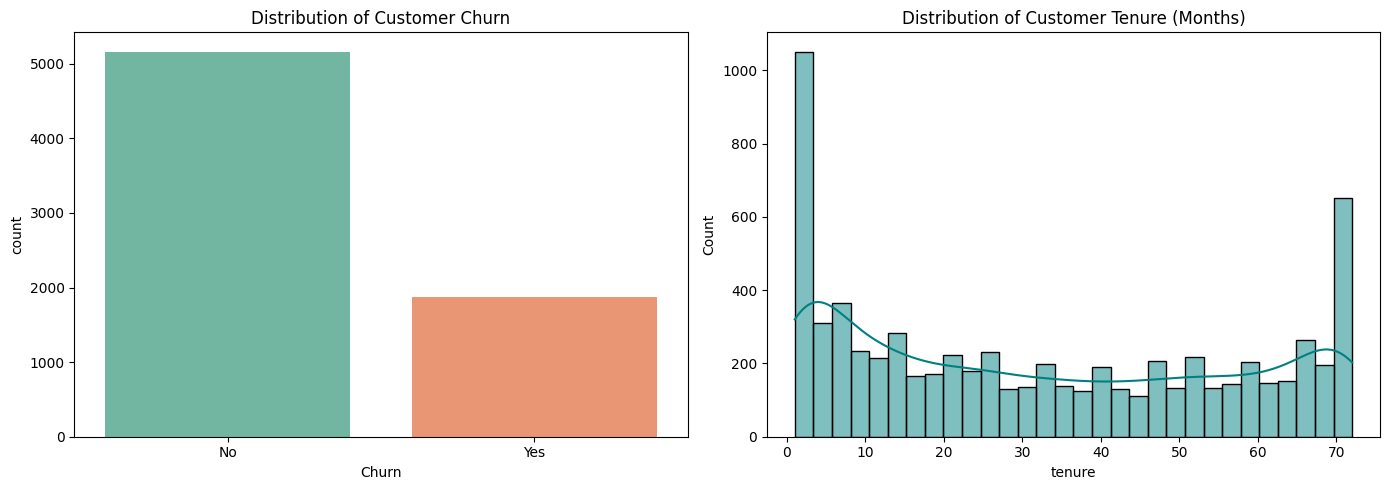

In [ ]:
# univariate
# This section visualises single variables to show their distribution (p. 4). The Churn count plot reveals a significant class imbalance, with many more customers staying than leaving (p. 4)
# The Tenure histogram shows high concentrations of both brand-new customers and very long-term (70+ months) loyal customers (p. 4).


plt.figure(figsize=(14, 5))

# Plot A: Target Variable (Churn) count
plt.subplot(1, 2, 1)
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Distribution of Customer Churn')

# Plot B: Distribution of Tenure (Histogram)
plt.subplot(1, 2, 2)
sns.histplot(df['tenure'], bins=30, kde=True, color='teal')
plt.title('Distribution of Customer Tenure (Months)')

plt.tight_layout()
plt.show()

/tmp/ipykernel_8147/1123503466.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set1')


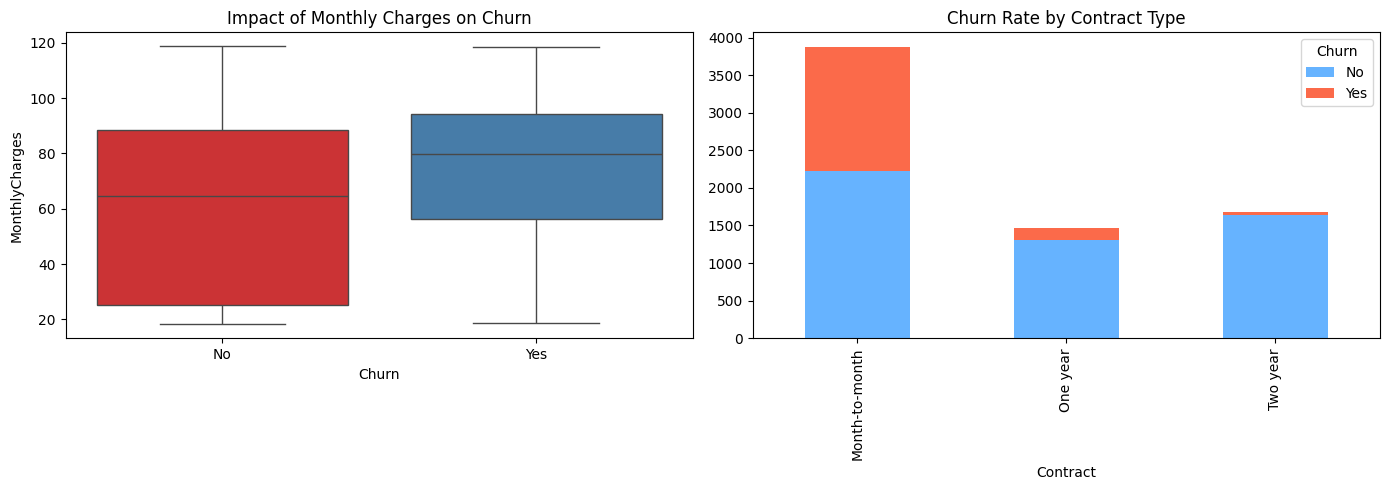

In [ ]:
# bivariate analysis
#  I compared key features against churn to find patterns (p. 5). The Monthly Charges vs. Churn boxplot indicates that customers who churn typically have higher median monthly charges (p. 5)
# The Contract Type bar chart shows a clear trend: customers on month-to-month contracts have a much higher churn rate compared to those on one or two-year plans (p. 5).


plt.figure(figsize=(14, 5))

# Plot A: Monthly Charges vs Churn (Boxplot)
plt.subplot(1, 2, 1)
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set1')
plt.title('Impact of Monthly Charges on Churn')

# Plot B: Contract Type vs Churn (Stack Bar)
plt.subplot(1, 2, 2)
churn_contract = df.groupby(['Contract', 'Churn']).size().unstack()
churn_contract.plot(kind='bar', stacked=True, ax=plt.gca(), color=['#66b3ff','#fb6a4a'])
plt.title('Churn Rate by Contract Type')

plt.tight_layout()
plt.show()

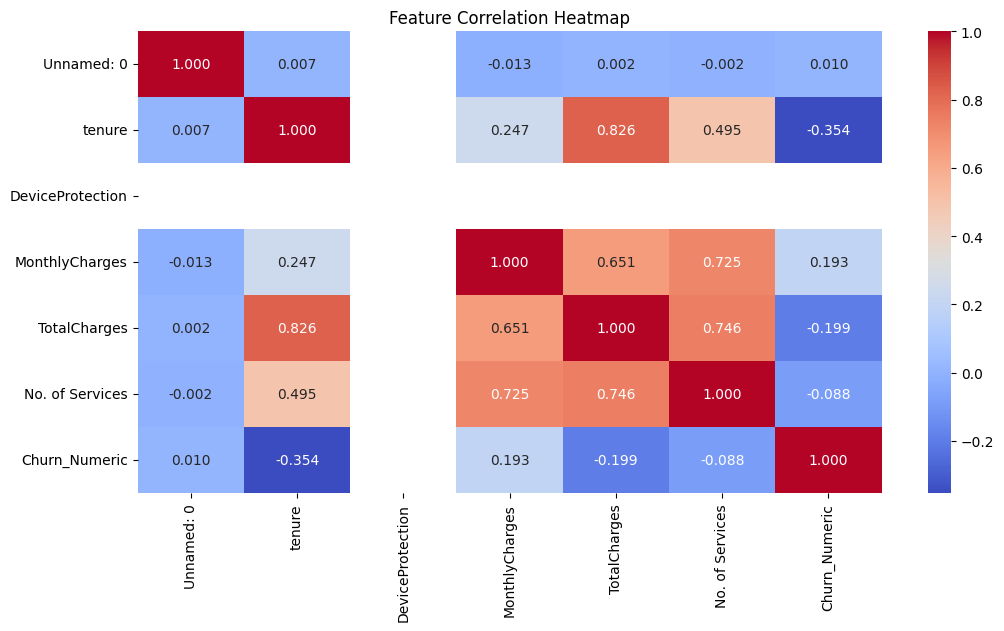

In [30]:
#eda analysiss(correlation)
#A heatmap was generated to show the linear relationship between numerical features and a numeric churn indicator (pp. 5-6)
#The output highlights a strong positive correlation between tenure and TotalCharges (0.83) (p. 6).
#It also shows a negative correlation (-0.35) between tenure and Churn_Numeric, suggesting that longer-tenured customers are less likely to churn (p. 6).
# Convert Churn to numeric for correlation mapping
df['Churn_Numeric'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

plt.figure(figsize=(12, 6))
correlation_matrix = df.select_dtypes(include=['number']).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.3f')
plt.title('Feature Correlation Heatmap')
plt.show()